# Demo: Market-Depth and Moving-Window Representations

This notebook samples a small number of limit-order-book snapshots from: `data/raw/XNAS_ITCH_AAPL_mbo_20251201_20260101.dbn.zst` using an event-based stride.

It then creates two sequence representations from `src/features/representation.py`:
- `moving_window`
- `market_depth`


In [39]:
from __future__ import annotations

from types import SimpleNamespace
from pathlib import Path

import databento as db
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("file"), "..")))
from src.features.representation import RepresentationTransform
from src.lob_implementation import Market, Book, LevelOrders

In [40]:
sample_every_n_events = 15  # sample one snapshot every M market-hours messages
max_samples = 20             # total number of snapshots to collect

dbn_path = Path('../data') / 'raw' / 'XNAS_ITCH_AAPL_mbo_20251201_20260101.dbn.zst'


In [41]:
def _snapshot_book(book: Book) -> Book:
    """Create a Book snapshot with only price/size information.

    This is to solve the problem of the book object being mutable but I can't deepcopy it...
    """
    snap = Book()

    for px, level in book.bids.items():
        size = int(level.level.size)
        if size <= 0:
            continue
        lv = LevelOrders(price=int(px))
        lv.orders = [SimpleNamespace(size=size, flags=0)]
        snap.bids[int(px)] = lv

    for px, level in book.offers.items():
        size = int(level.level.size)
        if size <= 0:
            continue
        lv = LevelOrders(price=int(px))
        lv.orders = [SimpleNamespace(size=size, flags=0)]
        snap.offers[int(px)] = lv

    return snap

# pre-processing copied from order_tracking.py
def sample_books_from_dbn(
    file_path: Path,
    sample_every_n_events: int,
    max_samples: int,
) -> tuple[list[Book], list[int], np.ndarray, np.ndarray, int, int]:
    """Sample Book snapshots from a DBN stream every M market-hours events.

    Also computes inter-event and inter-trade timing statistics for the target date only.
    Counts Trade (T) and Fill (F) actions during market hours.

    Returns:
        - sampled_books: list of Book snapshots
        - sampled_ts: list of timestamps (ns)
        - inter_event_times_us: inter-event times in microseconds
        - inter_trade_times_us: inter-trade times in microseconds
        - trade_count: number of Trade (T) actions
        - fill_count: number of Fill (F) actions
    """
    store = db.DBNStore.from_file(str(file_path))
    market = Market()

    sampled_books: list[Book] = []
    sampled_ts: list[int] = []

    inter_event_times_us = []
    inter_trade_times_us = []
    trade_count = 0
    fill_count = 0

    current_day = None
    day_start_ns: int | None = None
    day_end_ns: int | None = None
    target_day = None

    last_ts_ns_for_timing = None
    last_trade_ts_ns = None
    event_count = 0

    for mbo in store:
        market.apply(mbo)
        ts = int(mbo.ts_event)

        msg_day = int(ts // (86400 * 1e9))
        if msg_day != current_day:
            ts_dt = pd.to_datetime(ts, unit='ns', utc=True).tz_convert('America/New_York')
            local_midnight = pd.Timestamp(ts_dt.date()).tz_localize('America/New_York')
            day_start_dt = local_midnight + pd.Timedelta(hours=10, minutes=30)  # Market open (9:30 AM ET)
            day_end_dt = local_midnight + pd.Timedelta(hours=16, minutes=0)  # Market close (4:00 PM ET)
            day_start_ns = int(day_start_dt.tz_convert('UTC').value)
            day_end_ns = int(day_end_dt.tz_convert('UTC').value)
            current_day = msg_day

            # Set target_day on first market hours entry
            if target_day is None:
                target_day = msg_day

        if day_start_ns is None or day_end_ns is None:
            continue
        if ts < day_start_ns or ts > day_end_ns:
            continue

        # Only record timing data for the target date
        if msg_day > target_day:
            break
        if msg_day == target_day:
            # Compute inter-event time
            if last_ts_ns_for_timing is not None:
                delta_us = (ts - last_ts_ns_for_timing) / 1000.0
                inter_event_times_us.append(delta_us)
            last_ts_ns_for_timing = ts

            # Detect trades: action is "T" (Trade)
            if mbo.action == "T":
                if last_trade_ts_ns is not None:
                    delta_us = (ts - last_trade_ts_ns) / 1000.0
                    inter_trade_times_us.append(delta_us)
                last_trade_ts_ns = ts
                trade_count += 1
            elif mbo.action == "F":
                fill_count += 1

        event_count += 1
        if event_count % sample_every_n_events == 0 and len(sampled_books) < max_samples:
            book = market.get_book(mbo.instrument_id, mbo.publisher_id)

            best_bid, best_ask = book.bbo()
            if not best_bid or not best_ask:
                continue

            sampled_books.append(_snapshot_book(book))
            sampled_ts.append(ts)

    return sampled_books, sampled_ts, np.array(inter_event_times_us), np.array(inter_trade_times_us), trade_count, fill_count


In [42]:
sampled_books, sampled_ts, inter_event_times_us, inter_trade_times_us, trade_count, fill_count = sample_books_from_dbn(
    dbn_path,
    sample_every_n_events,
    max_samples
)

In [43]:
# Representation parameters
window = 20
tick_size = int(0.01 * 1e9)  # 1 cent in Databento units

moving_transform = RepresentationTransform(
    window=window,
    tick_size=tick_size,
    representation='moving_window',
)

depth_transform = RepresentationTransform(
    window=window,
    tick_size=tick_size,
    representation='market_depth',
)

moving_tensor = moving_transform.transform_sequence(sampled_books)
depth_tensor = depth_transform.transform_sequence(sampled_books)

print('moving_window shape:', tuple(moving_tensor.shape))
print('market_depth shape:', tuple(depth_tensor.shape))

moving_window shape: (20, 41)
market_depth shape: (20, 41)


In [44]:
last_book = sampled_books[-1]
best_bid = last_book.bbo()[0].price
bset_ask = last_book.bbo()[1].price
mid_price = 0.5 * (best_bid + bset_ask)
best_bid_offset = (best_bid - mid_price) / tick_size
best_ask_offset = (bset_ask - mid_price) / tick_size
print('book snapshot:')
print('best_bid:', best_bid)
print('best_ask:', bset_ask)
print('mid_price:', mid_price)
print('best_bid offset:', best_bid_offset)
print('best_ask offset:', best_ask_offset)

book snapshot:
best_bid: 278100000000
best_ask: 278150000000
mid_price: 278125000000.0
best_bid offset: -2.5
best_ask offset: 2.5


In [45]:
offsets = list(range(-window, window + 1))

moving_df = pd.DataFrame({
    'offset': offsets,
    'signed_volume': moving_tensor[-1].tolist(),
})

depth_df = pd.DataFrame({
    'offset': offsets,
    'cumulative_signed_depth': depth_tensor[-1].tolist(),
})

print('Last moving-window snapshot:')
display(moving_df)

print('Last market-depth snapshot:')
display(depth_df)

Last moving-window snapshot:


,offset,signed_volume
0,-20,-162.0
1,-19,-225.0
2,-18,-100.0
3,-17,-547.0
4,-16,-119.0
5,-15,-104.0
6,-14,-105.0
7,-13,-125.0
8,-12,-303.0
9,-11,-198.0


Last market-depth snapshot:


,offset,cumulative_signed_depth
0,-20,-4234.0
1,-19,-4072.0
2,-18,-3847.0
3,-17,-3747.0
4,-16,-3200.0
5,-15,-3081.0
6,-14,-2977.0
7,-13,-2872.0
8,-12,-2747.0
9,-11,-2444.0


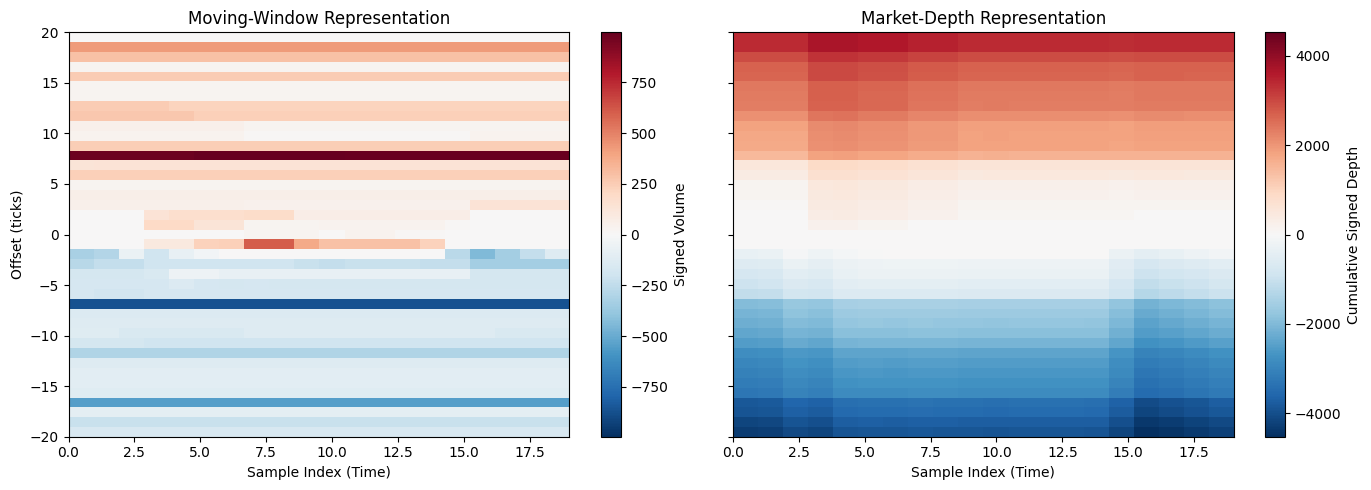

In [46]:
offsets = np.arange(-window, window + 1)
times_utc = pd.to_datetime(sampled_ts, unit='ns', utc=True)
times_et = times_utc.tz_convert('America/New_York')

vmax_moving = np.abs(moving_tensor).max()
vmax_depth = np.abs(depth_tensor).max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

im0 = axes[0].imshow(
    moving_tensor.T,
    aspect='auto',
    origin='lower',
    extent=[0, len(times_et)-1, offsets[0], offsets[-1]],
    cmap='RdBu_r',
    vmin=-vmax_moving, vmax=vmax_moving
    )
axes[0].set_title('Moving-Window Representation')
axes[0].set_xlabel('Sample Index (Time)')
axes[0].set_ylabel('Offset (ticks)')
fig.colorbar(im0, ax=axes[0], label='Signed Volume')

im1 = axes[1].imshow(
    depth_tensor.T,
    aspect='auto',
    origin='lower',
    extent=[0, len(times_et)-1, offsets[0], offsets[-1]],
    cmap='RdBu_r',
    vmin=-vmax_depth, vmax=vmax_depth
    )
axes[1].set_title('Market-Depth Representation')
axes[1].set_xlabel('Sample Index (Time)')
fig.colorbar(im1, ax=axes[1], label='Cumulative Signed Depth')

plt.tight_layout()
plt.show()